# 📊Data Analytics Internship Tasks - 2

**By Keerthan MS**
*B.Tech Computer Science & Engineering | Data Analytics Intern at ApexPlanet*

📫 **Let's Connect:**
* **Email:** keerthanms792004@gmail.com
* **LinkedIn:** www.linkedin.com/in/keerthan-ms-697368266
* **GitHub:** https://github.com/keerthan-ms/apexplanet-data-analytics/tree/main

In [1]:
import pandas as pd
import sqlite3

# 1. Load the cleaned data you created in Task 1
try:
    df = pd.read_csv("cleaned_customer_acquisition_data.csv")
    
    # 2. Connect to (or create) a local SQLite database file
    conn = sqlite3.connect('apexplanet_analytics.db')
    
    # 3. Write the data into a brand new SQL table called 'customer_data'
    df.to_sql('customer_data', conn, if_exists='replace', index=False)
    
    print("Database setup complete! Table 'customer_data' is ready for queries.")
except FileNotFoundError:
    print("Error: Could not find 'cleaned_customer_acquisition_data.csv'. Make sure the file name matches perfectly!")

Database setup complete! Table 'customer_data' is ready for queries.


In [2]:
# Query to see the first 5 rows of your data
query_1 = "SELECT * FROM customer_data LIMIT 5;"

# Run the query and display the results as a clean table
df_result = pd.read_sql_query(query_1, conn)
df_result

,customer_id,channel,cost,conversion_rate,revenue
0,1,referral,8.320327,0.123145,4199
1,2,paid advertising,30.450327,0.016341,3410
2,3,email marketing,5.246263,0.043822,3164
3,4,social media,9.546326,0.167592,1520
4,5,referral,8.320327,0.123145,2419


In [3]:
# Query to calculate performance metrics for each channel
query_2 = """
SELECT 
    channel,
    COUNT(customer_id) AS total_customers,
    ROUND(SUM(cost), 2) AS total_cost,
    ROUND(SUM(revenue), 2) AS total_revenue
FROM 
    customer_data
GROUP BY 
    channel
ORDER BY 
    total_revenue DESC;
"""

# Run the query and display the result
df_channel_performance = pd.read_sql_query(query_2, conn)
df_channel_performance

,channel,total_customers,total_cost,total_revenue
0,email marketing,214,1122.70,604706.0
1,referral,207,1722.31,569552.0
2,paid advertising,194,5907.36,548396.0
3,social media,185,1766.07,492667.0


In [4]:
# Query to calculate Return on Investment (ROI) per channel
query_3 = """
SELECT 
    channel,
    ROUND(((SUM(revenue) - SUM(cost)) / SUM(cost)) * 100, 2) AS roi_percentage
FROM 
    customer_data
GROUP BY 
    channel
ORDER BY 
    roi_percentage DESC;
"""
# Run the query and save it to the dataframe
df_roi = pd.read_sql_query(query_3, conn)

# Format the roi_percentage column and display the result
df_roi.style.format({'roi_percentage': '{:,.2f}%'})

# Run the query and display the result
df_roi.style.format({'roi_percentage': '{:,.2f}%'})
df_roi

,channel,roi_percentage
0,email marketing,53761.75
1,referral,32969.12
2,social media,27796.23
3,paid advertising,9183.26


### 📊 Business Insights: Return on Investment (ROI) by Channel

* **Top Performer:** **Email marketing** is driving the highest ROI by a massive margin (**53,761.75%**), making it the most cost-efficient channel for customer acquisition.
* **Strong Secondary Channels:** **Referrals** (32,969.12%) and **Social Media** (27,796.23%) both show robust returns, confirming the value of organic and network-driven acquisition.
* **Lowest Efficiency:** **Paid advertising** yields the lowest ROI (**9,183.26%**) among all tracked channels. 

**Strategic Takeaway:** To maximize capital efficiency, the budget should be heavily prioritized toward scaling email marketing efforts, while paid advertising spend requires an immediate audit to address severe cost inefficiencies.

<AxesSubplot:title={'center':'ROI Percentage by Channel'}, xlabel='channel'>

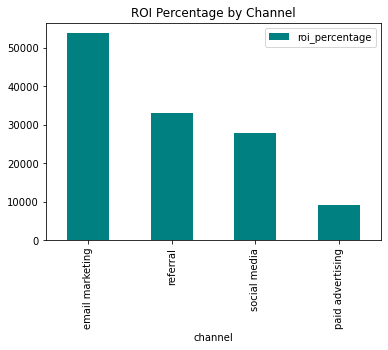

In [5]:
df_roi.plot(kind='bar', x='channel', y='roi_percentage', color='teal', title='ROI Percentage by Channel')

In [6]:
# Close the database connection
conn.close()